# Vibe 25 — Is this cooling valve hunting?

For **controls technicians**. We look at one analog output (cooling valve %) and ask:

> Is the valve settling, or is it swinging back and forth for a long time?

Open-FDD rule **PID-HUNT-1** is a screening tool. A flag means *suspected hunting* — not automatic proof that PID gains are wrong.

Helper code lives in Python modules under `vibe25/` (you import it; you do not need to read the math source).


## Install (once)

```text
pip install "open-fdd[oracle]" matplotlib
```

Or from this folder: `pip install -e ".[dev]"`


In [1]:
%pip install -q "open-fdd[oracle]>=4.4.1" matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
from vibe25 import (
    fault_summary,
    healthy_cooling_valve,
    hunting_midrange_sine_cooling_valve,
    hunting_sine_cooling_valve,
    plot_healthy_vs_hunting,
    plot_valve_overview,
    plot_valve_zoom_with_tv,
    run_pid_hunt,
)
import matplotlib.pyplot as plt


## 1. What hunting looks like (synthetic trends)

Left: a **healthy** valve that slowly opens — the kind of trend you want after a load change.

Right: a **hunting** sine wave — the command keeps oscillating instead of settling.


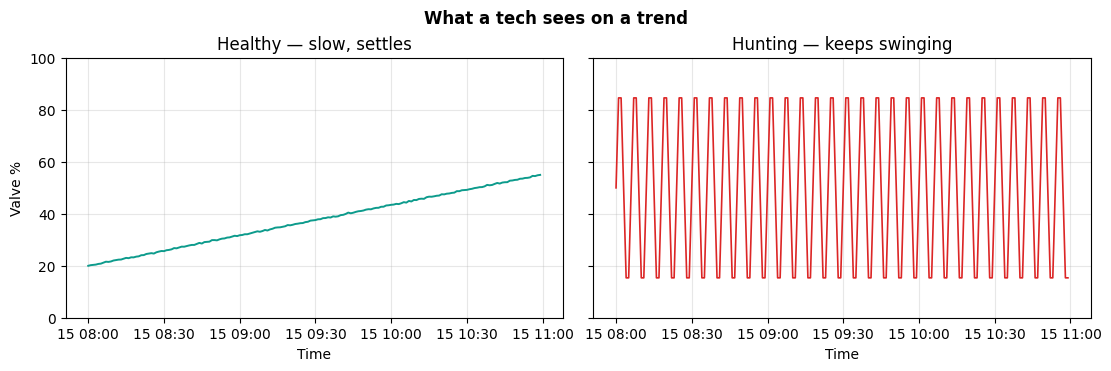

In [3]:
healthy = healthy_cooling_valve()
hunting = hunting_sine_cooling_valve()  # big swing ~10–90%

fig = plot_healthy_vs_hunting(healthy, hunting)
plt.show()


## 2. Full hunting trend + TV when the flag turns on

Pink band = hunting. Red dashed line = **first time fault becomes True**.

The callout shows the **rolling 1-hour TV** at that moment (how much travel was totalized in the last hour). Default trip needs TV ≥ 500 (plus span / cycles / reversals).


{'any_fault': True, 'fault_minutes': 133, 'max_tv_1h': 1385.6406460551038, 'max_span_1h': 69.2820323027561}


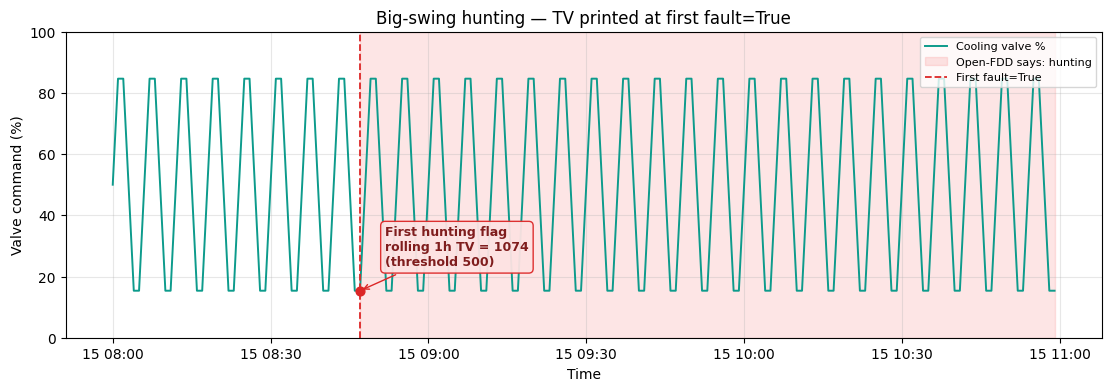

In [4]:
metrics = run_pid_hunt(hunting)
print(fault_summary(metrics))

fig = plot_valve_overview(
    hunting,
    metrics,
    title="Big-swing hunting — TV printed at first fault=True",
)
plt.show()


## 3. The math (rendered)

Open-FDD **PID-HUNT-1** treats the valve command $u_t$ (0–100%) like a travel odometer. Moves smaller than the deadband do not count.

### Deadbanded step

$$
\Delta u_t =
\begin{cases}
u_t - u_{t-1} & \text{if } |u_t - u_{t-1}| \ge 1\% \\
0 & \text{otherwise}
\end{cases}
$$

### Rolling 1-hour total variation (TV)

$$
\mathrm{TV}_{1\mathrm{h}}(t)
= \sum_{s \,\in\, [t-1\mathrm{h},\, t]} \lvert \Delta u_s \rvert
$$

### Span and equivalent cycles

$$
\mathrm{Span}_{1\mathrm{h}}(t)
= \max_{[t-1\mathrm{h},\, t]} u
- \min_{[t-1\mathrm{h},\, t]} u
$$

$$
\mathrm{Cycles}_{1\mathrm{h}}(t)
= \frac{\mathrm{TV}_{1\mathrm{h}}(t)}{2 \,\cdot\, \mathrm{Span}_{1\mathrm{h}}(t)}
$$

### Fault when *all* of these hold (defaults)

$$
\boxed{
\begin{aligned}
\mathrm{fault}(t)
&= \bigl(\mathrm{coverage}_{1\mathrm{h}} \ge 80\%\bigr) \\
&\quad\land\; \bigl(\mathrm{Span}_{1\mathrm{h}} \ge 20\%\bigr) \\
&\quad\land\; \bigl(\mathrm{TV}_{1\mathrm{h}} \ge 500\bigr) \\
&\quad\land\; \bigl(\mathrm{Cycles}_{1\mathrm{h}} \ge 2.5\bigr) \\
&\quad\land\; \bigl(\mathrm{reversals}_{1\mathrm{h}} \ge 4\bigr)
\end{aligned}
}
$$

TV is a **rolling** hour window — not a lifetime totalizer.


## 4. Zoom in — what is TV?

At **every** sample the plot shows:

- **Δ** = change from the *previous* sample (e.g. +35% or −35%)
- **Σ|Δ|** = add those absolute changes (odometer on this zoom: 35 → 70 → 105 …)
- **Purple dashed line** = Open-FDD **rolling 1-hour TV** (same idea, but over the trailing hour)
- **SPAN** = high − low (swing height) — orange bracket on the right


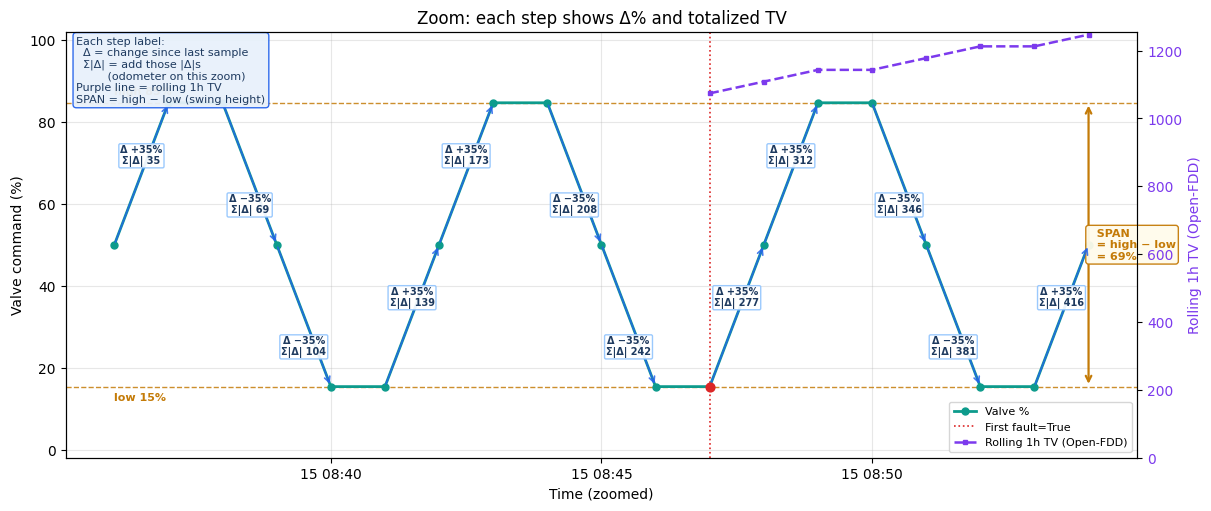

In [5]:
fig = plot_valve_zoom_with_tv(
    hunting,
    metrics,
    start_sample=36,
    n_cycles=3,
    period_samples=6,
    title="Zoom: each step shows Δ% and totalized TV",
)
plt.show()


## 5. Mid-range hunting (not 0–100%)

Hunting does **not** need to slam open/closed. This sine only swings about **40–70%** — still enough span (≥20) and travel to trip the same rule.


valve min/max: 42.00961894323327 67.99038105676681
{'any_fault': True, 'fault_minutes': 122, 'max_tv_1h': 519.615242270664, 'max_span_1h': 25.980762113533537}


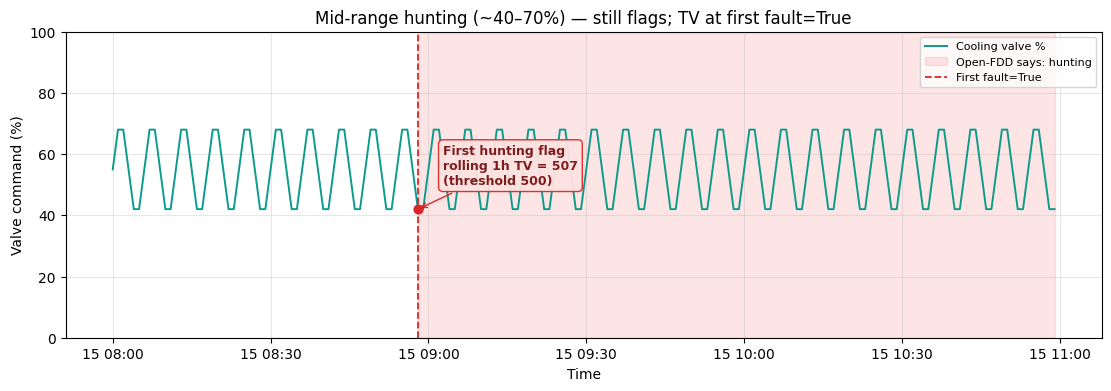

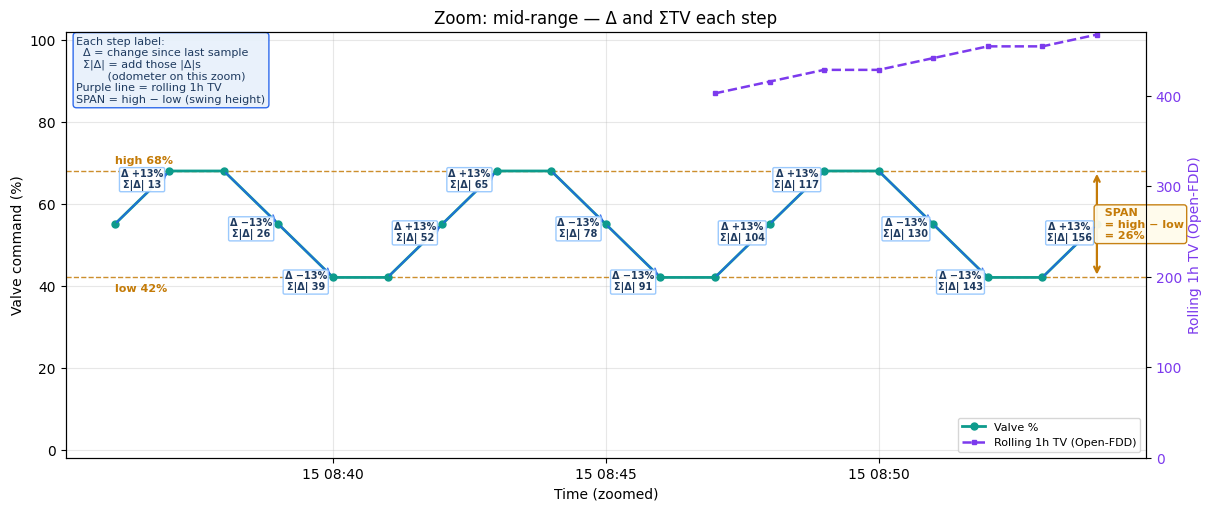

In [6]:
mid = hunting_midrange_sine_cooling_valve()  # ~40–70% only
mid_metrics = run_pid_hunt(mid)
print("valve min/max:", float(mid["cooling-valve"].min()), float(mid["cooling-valve"].max()))
print(fault_summary(mid_metrics))

fig = plot_valve_overview(
    mid,
    mid_metrics,
    title="Mid-range hunting (~40–70%) — still flags; TV at first fault=True",
)
plt.show()

fig = plot_valve_zoom_with_tv(
    mid,
    mid_metrics,
    start_sample=36,
    n_cycles=3,
    period_samples=6,
    title="Zoom: mid-range — Δ and ΣTV each step",
)
plt.show()


## 6. Healthy check (should stay clear)

Same detector on the slow ramp. You should see **no** hunting flag and a tiny TV.


{'any_fault': False, 'fault_minutes': 0, 'max_tv_1h': 0.0, 'max_span_1h': 12.089720823223054}


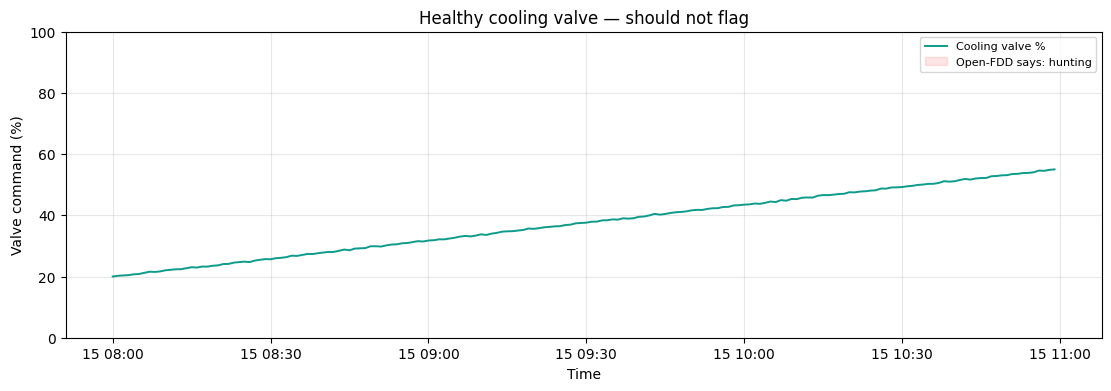

In [7]:
ok_metrics = run_pid_hunt(healthy)
print(fault_summary(ok_metrics))

fig = plot_valve_overview(
    healthy,
    ok_metrics,
    title="Healthy cooling valve — should not flag",
)
plt.show()


## Tech takeaways

| Word | Plain English |
|------|----------------|
| Valve % | Analog command / position (0–100) |
| Span | High − low of the swing (can be mid-range, not full stroke) |
| TV | Rolling 1h travel (sum of ups and downs) |
| Hunting flag | Too much travel for too long — shown with TV at first True |

Use this on real historian data the same way: put valve % on a time index, call `run_pid_hunt(df)`.

Helper modules: `vibe25.synth`, `vibe25.detect`, `vibe25.plotting`.
